In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.formula.api import ols as ols_formula
from statsmodels.stats.anova import anova_lm

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFECV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [2]:
# ── Load data & drop leaked / constant columns ───────────────────────────────
houses = pd.read_excel("../segmentation/cluster_0_phase2_DBSCAN.xlsx")

# cluster and cluster_wd are segmentation labels — using them as features
# would be data leakage (they encode information derived from the target).
houses.drop(columns=["cluster", "cluster_wd"], inplace=True)

# In DBSCAN cluster 0 every listing is outer=1, elevator=1, penthouse=0,
# cottage=0, duplex=0, semidetached=0.  Zero-variance columns add nothing
# to a regression and cause numerical issues (VIF = NaN / inf).
const_cols = [c for c in houses.columns
              if c != "rent" and houses[c].nunique() <= 1]
print(f"Dropping constant columns: {const_cols}")
houses.drop(columns=const_cols, inplace=True)

print(f"\nShape after cleaning: {houses.shape}")
houses.head()

Dropping constant columns: ['outer', 'elevator', 'penthouse', 'cottage', 'duplex', 'semidetached']

Shape after cleaning: (1248, 5)


,district,rent,bedrooms,square_meters,floor
0,Ciudad Lineal,1300,2,72,3.0
1,Ciudad Lineal,1300,2,100,3.0
2,Ciudad Lineal,1600,3,120,4.0
3,Ciudad Lineal,850,1,60,3.0
4,Ciudad Lineal,850,1,52,1.0


In [3]:
# ── Check for missing values ─────────────────────────────────────────────────
houses.isna().sum()

district         0
rent             0
bedrooms         0
square_meters    0
floor            0
dtype: int64

## Train–test split — single 80 / 20

One split only. The original notebook split twice (80/20 → 80/20), leaving
just 64 % of the data for training.

In [4]:
# ── Single 80/20 train-test split ────────────────────────────────────────────
X = houses.drop(columns=["rent"])
y = houses["rent"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows")

Train: 998 rows  |  Test: 250 rows


In [5]:
# ── One-hot encode district ──────────────────────────────────────────────────
# Ciudad Lineal is the reference category (its dummy is dropped).
# Train and test are encoded separately; test columns are aligned to train
# via reindex so missing districts get 0 and column order matches.

# Encode train
dummies_train = pd.get_dummies(X_train["district"], dtype=float)
X_train = pd.concat([X_train.drop(columns="district"), dummies_train], axis=1)
X_train.drop(columns="Ciudad Lineal", inplace=True)

# Encode test & align columns to train
dummies_test = pd.get_dummies(X_test["district"], dtype=float)
X_test = pd.concat([X_test.drop(columns="district"), dummies_test], axis=1)
X_test.drop(columns="Ciudad Lineal", inplace=True, errors="ignore")
X_test = X_test.reindex(columns=X_train.columns, fill_value=0.0)

print(f"Features after encoding: {X_train.shape[1]}")
X_train.head()

Features after encoding: 22


,bedrooms,square_meters,floor,Arganzuela,Barajas,Carabanchel,Centro,Chamartín,Chamberí,Fuencarral,...,Moncloa,Moratalaz,Puente Vallecas,Retiro,Salamanca,San Blás,Tetuán,Usera,Vicálvaro,Villa de Vallecas
924,1,60,0.5,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1161,1,62,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1112,2,105,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1006,2,152,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1031,4,192,7.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


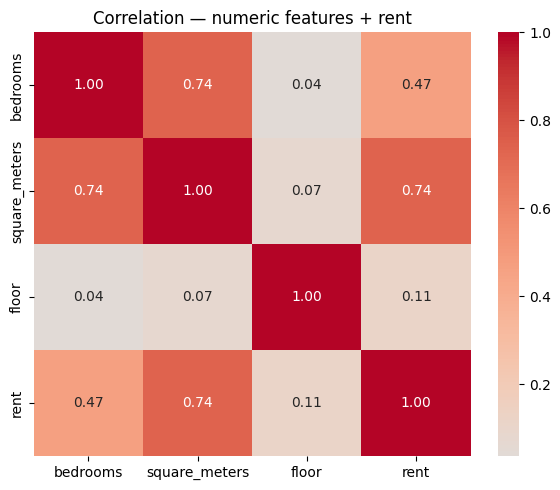

In [6]:
# ── Correlation heatmap (numeric features only) ──────────────────────────────
numeric_cols = ["bedrooms", "square_meters", "floor"]
corr_df = X_train[numeric_cols].copy()
corr_df["rent"] = y_train.values
corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation — numeric features + rent")
plt.tight_layout()
plt.show()

In [7]:
# ── VIF on numeric features only ─────────────────────────────────────────────
# VIF is only meaningful for continuous / ordinal features.  Including
# one-hot dummies inflates VIF to infinity because the dummies are linearly
# dependent as a group.
numeric_cols = ["bedrooms", "square_meters", "floor"]

vif_data = pd.DataFrame({
    "Variable": numeric_cols,
    "VIF": [variance_inflation_factor(X_train[numeric_cols].values, i)
            for i in range(len(numeric_cols))]
})
print("VIF (numeric features only — dummies excluded):\n")
print(vif_data.sort_values("VIF", ascending=False).to_string(index=False))

VIF (numeric features only — dummies excluded):

     Variable       VIF
square_meters 11.914589
     bedrooms 11.366186
        floor  2.205171


RFECV selected 19 features:
['bedrooms', 'square_meters', 'floor', 'Carabanchel', 'Centro', 'Chamartín', 'Chamberí', 'Fuencarral', 'Latina', 'Moncloa', 'Moratalaz', 'Puente Vallecas', 'Retiro', 'Salamanca', 'San Blás', 'Tetuán', 'Usera', 'Vicálvaro', 'Villa de Vallecas']


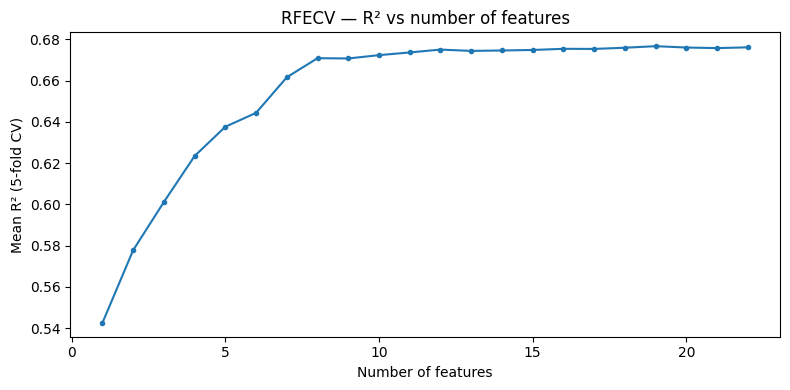

In [8]:
# ── RFECV (Recursive Feature Elimination with Cross-Validation) ──────────────
# Scale features manually so the bare LinearRegression estimator works on
# comparable scales.  We do NOT wrap it in a Pipeline — RFECV needs direct
# access to the estimator's coef_ attribute.
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index,
)

rfecv = RFECV(
    estimator=LinearRegression(),
    step=1,
    cv=5,
    scoring="r2",
    min_features_to_select=1,
)
rfecv.fit(X_train_scaled, y_train)

selected = X_train.columns[rfecv.support_].tolist()
print(f"RFECV selected {len(selected)} features:")
print(selected)

# Plot CV R² vs number of features
fig, ax = plt.subplots(figsize=(8, 4))
scores = rfecv.cv_results_["mean_test_score"]
ax.plot(range(1, len(scores) + 1), scores, marker="o", markersize=3)
ax.set_xlabel("Number of features")
ax.set_ylabel("Mean R² (5-fold CV)")
ax.set_title("RFECV — R² vs number of features")
plt.tight_layout()
plt.show()

In [9]:
# ── Backward elimination (p > 0.05) on RAW data ──────────────────────────────
# Fitting OLS on unscaled data so every coefficient is directly interpretable
# in EUR (e.g. "+15 EUR per extra floor").

def backward_elimination(X, y, threshold=0.05):
    """Drop the feature with the highest p-value above *threshold*,
    one at a time, until all remaining features are significant."""
    features = list(X.columns)
    while features:
        X_const = sm.add_constant(X[features])
        model = sm.OLS(y, X_const).fit()
        # p-values for predictors only (exclude the intercept)
        pvals = model.pvalues[model.pvalues.index != "const"]
        worst_pval = pvals.max()
        if worst_pval > threshold:
            worst_feat = pvals.idxmax()
            print(f"  Dropping '{worst_feat}' (p = {worst_pval:.4f})")
            features.remove(worst_feat)
        else:
            break
    return model, features

# Start from the RFECV-selected features
model_ols, final_features = backward_elimination(
    X_train[selected], y_train, threshold=0.05
)

print(f"\nFinal features ({len(final_features)}):")
print(final_features)
print(model_ols.summary())

  Dropping 'Latina' (p = 0.2626)
  Dropping 'Carabanchel' (p = 0.3176)
  Dropping 'Puente Vallecas' (p = 0.3753)
  Dropping 'San Blás' (p = 0.2281)
  Dropping 'Villa de Vallecas' (p = 0.2766)
  Dropping 'Fuencarral' (p = 0.3132)
  Dropping 'Usera' (p = 0.3172)
  Dropping 'Moratalaz' (p = 0.1442)

Final features (11):
['bedrooms', 'square_meters', 'floor', 'Centro', 'Chamartín', 'Chamberí', 'Moncloa', 'Retiro', 'Salamanca', 'Tetuán', 'Vicálvaro']
                            OLS Regression Results                            
Dep. Variable:                   rent   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.679
Method:                 Least Squares   F-statistic:                     192.3
Date:                Sat, 28 Feb 2026   Prob (F-statistic):          2.05e-236
Time:                        14:25:26   Log-Likelihood:                -7541.0
No. Observations:                 998   AIC:                         1.511e+

In [10]:
# ── 5-fold cross-validation ──────────────────────────────────────────────────
# Using a Pipeline so that scaling happens inside each fold (no leakage).
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LinearRegression()),
])

cv = cross_validate(
    pipe,
    X_train[final_features],
    y_train,
    cv=5,
    scoring=["r2", "neg_mean_squared_error"],
)

r2_cv = cv["test_r2"]
rmse_cv = np.sqrt(-cv["test_neg_mean_squared_error"])

print(f"5-fold CV  R²:   {r2_cv.mean():.3f} ± {r2_cv.std():.3f}")
print(f"5-fold CV RMSE:  {rmse_cv.mean():.0f} ± {rmse_cv.std():.0f} EUR")

5-fold CV  R²:   0.675 ± 0.030
5-fold CV RMSE:  468 ± 32 EUR


In [11]:
# ── Test-set evaluation ──────────────────────────────────────────────────────
X_test_final = sm.add_constant(X_test[final_features])
y_pred_test = model_ols.predict(X_test_final)

r2  = r2_score(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae  = mean_absolute_error(y_test, y_pred_test)

print(f"Test R²:   {r2:.3f}")
print(f"Test RMSE: {rmse:.0f} EUR")
print(f"Test MAE:  {mae:.0f} EUR")

Test R²:   0.654
Test RMSE: 466 EUR
Test MAE:  326 EUR


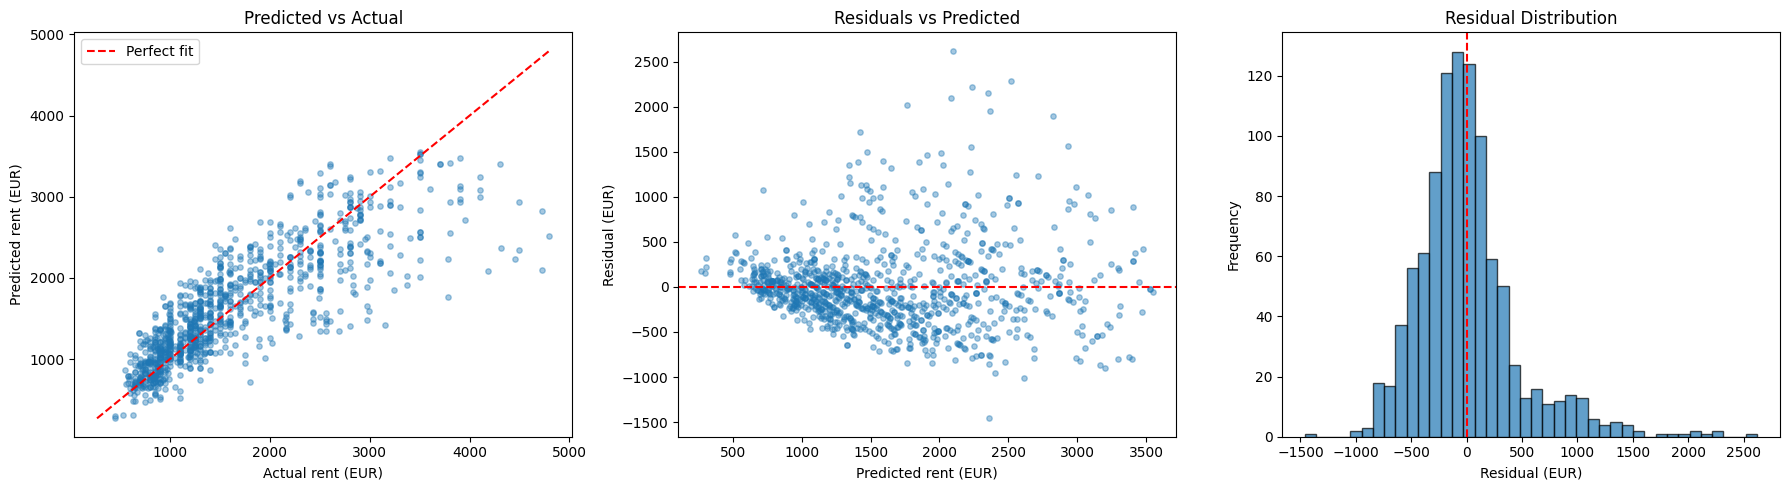

In [12]:
# ── Residual diagnostics ─────────────────────────────────────────────────────
y_pred_train = model_ols.predict(sm.add_constant(X_train[final_features]))
residuals = y_train - y_pred_train

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Predicted vs actual
axes[0].scatter(y_train, y_pred_train, alpha=0.4, s=15)
lims = [min(y_train.min(), y_pred_train.min()),
        max(y_train.max(), y_pred_train.max())]
axes[0].plot(lims, lims, "r--", label="Perfect fit")
axes[0].set_xlabel("Actual rent (EUR)")
axes[0].set_ylabel("Predicted rent (EUR)")
axes[0].set_title("Predicted vs Actual")
axes[0].legend()

# 2. Residuals vs predicted
axes[1].scatter(y_pred_train, residuals, alpha=0.4, s=15)
axes[1].axhline(0, color="r", linestyle="--")
axes[1].set_xlabel("Predicted rent (EUR)")
axes[1].set_ylabel("Residual (EUR)")
axes[1].set_title("Residuals vs Predicted")

# 3. Residual histogram
axes[2].hist(residuals, bins=40, edgecolor="black", alpha=0.7)
axes[2].axvline(0, color="r", linestyle="--")
axes[2].set_xlabel("Residual (EUR)")
axes[2].set_ylabel("Frequency")
axes[2].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

In [13]:
# ── ANOVA Type II ────────────────────────────────────────────────────────────
# The statsmodels formula API requires Python-safe column names,
# so we temporarily rename columns that contain spaces or accents.
rename_map = {}
for c in final_features:
    safe = (c.replace(" ", "_")
             .replace("\u00e1", "a")   # á → a
             .replace("\u00e9", "e")   # é → e
             .replace("\u00ed", "i")   # í → i
             .replace("\u00fa", "u"))  # ú → u
    rename_map[c] = safe

df_anova = X_train[final_features].rename(columns=rename_map).copy()
df_anova["rent"] = y_train

formula = "rent ~ " + " + ".join(rename_map.values())
model_anova = ols_formula(formula, data=df_anova).fit()
anova_table = anova_lm(model_anova, typ=2)

# Add significance stars
def _signif(p):
    if pd.isna(p): return ""
    if p < 0.001:  return "***"
    if p < 0.01:   return "**"
    if p < 0.05:   return "*"
    return ""

anova_table["Signif"] = anova_table["PR(>F)"].apply(_signif)
anova_table.round(4)

,sum_sq,df,F,PR(>F),Signif
bedrooms,1.392868e+06,1.0,6.4266,0.0114,*
square_meters,1.412612e+08,1.0,651.7693,0.0000,***
floor,1.317479e+06,1.0,6.0788,0.0139,*
Centro,3.117765e+07,1.0,143.8514,0.0000,***
Chamartin,1.616485e+07,1.0,74.5835,0.0000,***
Chamberi,2.678108e+07,1.0,123.5660,0.0000,***
Moncloa,9.522441e+06,1.0,43.9359,0.0000,***
Retiro,1.058012e+07,1.0,48.8159,0.0000,***
Salamanca,5.307690e+07,1.0,244.8930,0.0000,***
Tetuan,4.135478e+06,1.0,19.0808,0.0000,***


In [14]:
# ── Undervalued / overvalued listings (test set) ─────────────────────────────
df_eval = houses.loc[X_test.index].copy()
df_eval["predicted_rent"] = y_pred_test.values
df_eval["residual"] = df_eval["rent"] - df_eval["predicted_rent"]

cols_show = ["district", "rent", "predicted_rent", "residual",
             "bedrooms", "square_meters", "floor"]

print("Top 20 UNDERVALUED (actual << predicted — possible bargains):\n")
display(df_eval.nsmallest(20, "residual")[cols_show].reset_index(drop=True))

print("\nTop 20 OVERVALUED (actual >> predicted — possibly overpriced):\n")
display(df_eval.nlargest(20, "residual")[cols_show].reset_index(drop=True))

Top 20 UNDERVALUED (actual << predicted — possible bargains):



,district,rent,predicted_rent,residual,bedrooms,square_meters,floor
0,Chamartín,2200,3057.598636,-857.598636,3,210,5.0
1,Salamanca,1450,2236.427862,-786.427862,3,120,5.0
2,Salamanca,1250,2034.443739,-784.443739,2,100,5.0
3,Moncloa,1100,1884.372375,-784.372375,3,120,3.0
4,Fuencarral,1300,2039.877266,-739.877266,2,160,5.0
5,Chamberí,1700,2436.055921,-736.055921,3,140,9.0
6,Moncloa,800,1526.857477,-726.857477,2,90,1.0
7,Moncloa,450,1170.147394,-720.147394,2,60,3.0
8,Salamanca,1200,1845.617964,-645.617964,4,98,1.0
9,Chamartín,1100,1739.632130,-639.632130,2,105,3.0



Top 20 OVERVALUED (actual >> predicted — possibly overpriced):



,district,rent,predicted_rent,residual,bedrooms,square_meters,floor
0,Salamanca,4300,1837.707124,2462.292876,2,90,0.0
1,Salamanca,3800,2162.503953,1637.496047,2,110,5.0
2,Tetuán,2750,1157.519078,1592.480922,3,80,1.0
3,Moncloa,2970,1516.113574,1453.886426,2,72,17.0
4,Chamartín,2700,1278.739802,1421.260198,1,68,0.0
5,Salamanca,3995,2647.274251,1347.725749,2,150,3.0
6,Salamanca,3500,2254.004621,1245.995379,2,115,7.0
7,Chamberí,3000,1821.615779,1178.384221,1,90,3.0
8,Retiro,4500,3335.772624,1164.227376,2,220,3.0
9,Centro,2600,1466.786426,1133.213574,2,70,3.0
